# this is to see if we can link enhancers and promoters, it's mostly or all in K562

In [2]:
#kushal has data for it in HG38, so we'll use that

import pandas as pd
path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
df = pd.read_csv(path, sep="\t")
df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,"Gasperini et al., 2019",False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,"Gasperini et al., 2019",False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,"Gasperini et al., 2019",False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408


In [3]:
df['CellType'].unique() #yes all K562

array(['K562'], dtype=object)

In [4]:
df['Reference'].unique() #the three are the crispri flowfish, gasperini, and tapseq

array(['Ulirsch2016', 'Gasperini et al., 2019', 'Wakabayashi2016',
       'Schraivogel et al., 2020', 'Klann2017', 'Thakore2015', 'Xie2017',
       'Fulco2019', 'Qi2018', 'Huang2018', 'Xu2015', 'Fulco2016'],
      dtype=object)

In [5]:
df['ValidConnection'].unique() #all are valid connections, so we don't need to do this

array([ True])

In [6]:
#see if Regulated and Significant are elementwise same
df['Regulated'].equals(df['Significant']) #yes, so we can just use one of them

False

In [7]:
df[df['Regulated'] != df['Significant']]


,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
19,Gasperini2019,chr1,17487740,17488240,RP4-798A10.7|chr1:17814236-17814736:.,0.039664,chr1,16514645.0,16514646.0,RP4-798A10.7,...,"Gasperini et al., 2019",False,0.05,0.05,0.05,0.45,Gasperini2019|RP4-798A10.7|chr1:17814236-17814...,20,17487740,17488240
101,Gasperini2019,chr1,26619808,26621780,PIGV|chr1:26946299-26948271:.,0.019576,chr1,26787472.0,26787473.0,PIGV,...,"Gasperini et al., 2019",False,0.00,0.15,0.25,0.80,Gasperini2019|PIGV|chr1:26946299-26948271:.,102,26619808,26621780
304,Gasperini2019,chr1,46244926,46245636,RP1-18D14.7|chr1:46710598-46711308:.,0.002855,chr1,47225797.0,47225798.0,RP1-18D14.7,...,"Gasperini et al., 2019",False,0.00,0.00,0.00,0.00,Gasperini2019|RP1-18D14.7|chr1:46710598-467113...,305,46244926,46245636
313,Gasperini2019,chr1,46522169,46522839,PDZK1IP1|chr1:46987841-46988511:.,0.010174,chr1,47191043.0,47191044.0,PDZK1IP1,...,"Gasperini et al., 2019",False,0.00,0.00,0.00,0.00,Gasperini2019|PDZK1IP1|chr1:46987841-46988511:.,314,46522169,46522839
360,Gasperini2019,chr1,92990780,92991280,RPL5|chr1:93456337-93456837:.,0.104610,chr1,92832025.0,92832026.0,RPL5,...,"Gasperini et al., 2019",False,0.90,0.90,0.95,1.00,Gasperini2019|RPL5|chr1:93456337-93456837:.,361,92990780,92991280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999,FlowFISH_K562,chrX,48794818,48795318,PLP2|chrX:48653225-48653725:*,0.075890,chrX,49171926.0,49171927.0,PLP2,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|PLP2|chrX:48653225-48653725:*,10000,48794818,48795318
10001,FlowFISH_K562,chrX,48800418,48800918,PLP2|chrX:48658825-48659325:*,0.225423,chrX,49171926.0,49171927.0,PLP2,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|PLP2|chrX:48658825-48659325:*,10002,48800418,48800918
10208,FlowFISH_K562,chrX,48794198,48794758,PQBP1|chrX:48652605-48653165:*,0.101145,chrX,48897912.0,48897913.0,PQBP1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|PQBP1|chrX:48652605-48653165:*,10209,48794198,48794758
10241,FlowFISH_K562,chrX,49083332,49084594,PQBP1|chrX:48940985-48941505:*,0.179749,chrX,48897912.0,48897913.0,PQBP1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|PQBP1|chrX:48940985-48941505:*,10242,49083332,49084594


## notes from meeting with karthik

numbers in name is hg19, ignore that use the hg38 ones with chrom start end

all crispri, not all perturb seq

just do regulated column for it

drop NAs

supplementary notes of re2g can be helpful for this

Questions are how does graph reg do this with gradients, can you do ISM by perturbing or setting accessibility to 0, but not masked

# let's load the k562 DNase track and just see if most or all of these are already peaks

In [8]:
#I expect many of them to not be, so let's check, we have one DNase track, but can load others if needed

import pandas as pd
import numpy as np
path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
df = pd.read_csv(path, sep="\t")

k562_file = '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/K562_DNase.npz'
with np.load(k562_file) as k562_file:
    k562 = {key: np.array(k562_file[key]) for key in k562_file}

In [13]:
temp = df.iloc[0]
chrom = temp['chrom']
start = temp['chromStart']
end = temp['chromEnd']
track = k562[chrom][0,start-50:end+50]
track.shape

(600,)

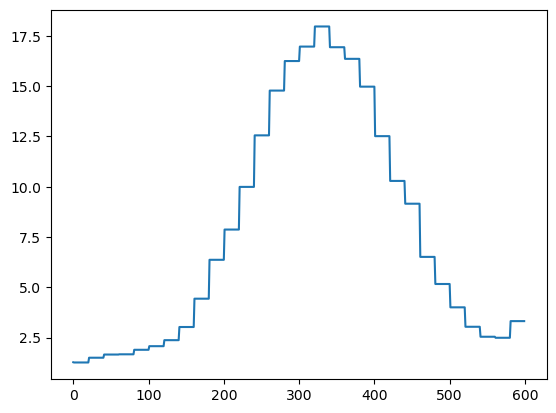

In [ ]:
import matplotlib.pyplot as plt
plt.plot(track) #is

# much later revisiting

In [1]:
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
#this is the bounds with 500 bp. But we don't have all of those in the gold standard set
gs_file = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
import pandas as pd

gs_df = pd.read_csv(gs_file, sep='\t')
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,"Gasperini et al., 2019",False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,"Gasperini et al., 2019",False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,"Gasperini et al., 2019",False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408


In [5]:
tss = pd.read_csv(TSS_bounds_file, sep='\t')
tss

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
0,chr1,35831,36331,FAM138A,0,-,ENSG00000237613,lincRNA
1,chr1,35831,36331,FAM138F,0,-,ENSG00000282591,lincRNA
2,chr1,68840,69340,OR4F5,0,+,ENSG00000186092,protein_coding
3,chr1,817120,817620,FAM87B,0,+,ENSG00000177757,lincRNA
4,chr1,827272,827772,LINC00115,0,-,ENSG00000225880,lincRNA
...,...,...,...,...,...,...,...,...
20662,chrY,21386110,21386610,PRORY,0,-,ENSG00000183146,protein_coding
20663,chrY,21594416,21594916,TTTY13,0,-,ENSG00000184991,lincRNA
20664,chrY,22298626,22299126,TTTY5,0,-,ENSG00000215560,lincRNA
20665,chrY,23198842,23199342,DAZ1,0,-,ENSG00000188120,protein_coding


In [3]:
gs_df.columns

Index(['dataset', 'chrom', 'chromStart', 'chromEnd', 'name', 'EffectSize',
       'chrTSS', 'startTSS', 'endTSS', 'measuredGeneSymbol', 'Significant',
       'pValueAdjusted', 'PowerAtEffectSize25', 'ValidConnection', 'CellType',
       'Reference', 'Regulated', 'PowerAtEffectSize10', 'PowerAtEffectSize15',
       'PowerAtEffectSize20', 'PowerAtEffectSize50', 'pair_uid', 'merged_uid',
       'merged_start', 'merged_end'],
      dtype='object')

In [4]:
gs_df['Regulated'].value_counts() #mostly negatives? yes 10K positives and negatives?

Regulated
False    9924
True      487
Name: count, dtype: int64

In [7]:
#let's looka t a specific one and ensure that the TSS bounds are HG38
tss[tss['name'] == 'CEP104']

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
80,chr1,3856983,3857483,CEP104,0,-,ENSG00000116198,protein_coding


In [ ]:
3857483-3856983 #yeah 500 in length total, whereas they do just 1 bp for their TSS

500

In [ ]:
#let's get the midpoint of these
tss[tss['name'] == 'CEP104']['start'] + 250 #slightly off from the TSS, but not that far?

80    3857233
Name: start, dtype: int64

In [12]:
for index, row in gs_df.iterrows():
    # chrom = row['chrom']
    # start = row['chromStart']
    # end = row['chromEnd']
    protein_name = row['measuredGeneSymbol']
    tss_row = tss[tss['name'] == protein_name]
    if tss_row.empty:
        print(f"No TSS bounds found for {protein_name}")
    else:
        midpoint = tss_row['start'].values[0] + 250
        labels = row['startTSS']
        print(f"{protein_name}: difference in TSS sites {midpoint - labels}")
        #but the labels are 
    if index == 10: #just check the first 10
        break

CEP104: difference in TSS sites 20.0
LRRC47: difference in TSS sites 1.0
LRRC47: difference in TSS sites 1.0
SMIM1: difference in TSS sites 25.0
SMIM1: difference in TSS sites -2.0
SMIM1: difference in TSS sites -2.0
RPL22: difference in TSS sites -9769.0
PARK7: difference in TSS sites 7362.0
PARK7: difference in TSS sites 7362.0
ENO1: difference in TSS sites -156.0
ENO1: difference in TSS sites -156.0


In [ ]:
#ok so for this we'll have to use the TSS start sites from the file Kushal gave us. It's fine can just use the gene name I guess??

# more QC, look at and drop some rows from the gold standard file

Then ensure that the TSS is at least near the canonical TSS file!

In [ ]:
#we need to drop rows that have a Nan in the regulated column or if the location is Nan



# basic idea and questions

So start and end is the enhancer start and end? Yes it is

center at canonical TSS (is it the same as the chr start and end for the TSS in the file). Should be, check

Are those the only columns I need (along with regulated). pretty much, there's code somewhere of it

Then perturb enhancer, see downstream effect on expression, quantify it. Then use these scores to produce auprc? Check the code

In [ ]:
#first let's quickly verify the TSS sites are correct
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
#this is the bounds with 500 bp. But we don't have all of those in the gold standard set
gs_file = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
import pandas as pd

gs_df = pd.read_csv(gs_file, sep='\t')
tss = pd.read_csv(TSS_bounds_file, sep='\t')

gs_df.iloc[0]

dataset                                              FlowFISH_K562
chrom                                                         chr1
chromStart                                                 3774714
chromEnd                                                   3775214
name                                 CEP104|chr1:3691278-3691778:*
EffectSize                                               -0.293432
chrTSS                                                        chr1
startTSS                                                 3857213.0
endTSS                                                   3857214.0
measuredGeneSymbol                                          CEP104
Significant                                                   True
pValueAdjusted                                            0.004024
PowerAtEffectSize25                                       0.825094
ValidConnection                                               True
CellType                                                      

In [2]:
tss

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
0,chr1,35831,36331,FAM138A,0,-,ENSG00000237613,lincRNA
1,chr1,35831,36331,FAM138F,0,-,ENSG00000282591,lincRNA
2,chr1,68840,69340,OR4F5,0,+,ENSG00000186092,protein_coding
3,chr1,817120,817620,FAM87B,0,+,ENSG00000177757,lincRNA
4,chr1,827272,827772,LINC00115,0,-,ENSG00000225880,lincRNA
...,...,...,...,...,...,...,...,...
20662,chrY,21386110,21386610,PRORY,0,-,ENSG00000183146,protein_coding
20663,chrY,21594416,21594916,TTTY13,0,-,ENSG00000184991,lincRNA
20664,chrY,22298626,22299126,TTTY5,0,-,ENSG00000215560,lincRNA
20665,chrY,23198842,23199342,DAZ1,0,-,ENSG00000188120,protein_coding


In [ ]:
# gs_df = gs_df[gs_df['geneType'] == 'protein_coding']


In [ ]:
#we have ot use gene symbol
#first subset to protein coding
#now let's loop through it, get the name, get the sub gs df and then compare tss
for index, row in tss.iterrows():
    name = row['name']
    sub_gs_df = gs_df[gs_df['measuredGeneSymbol'] == name]
    if sub_gs_df.empty:
        2
        # print(f"No entries in gold standard for {name}")
    else:
        print(index)
        print(row)
        # print(sub_gs_df)
        # sub_gs_df
        break

78
#chr                     chr1
start                 3772536
end                   3773036
name                    SMIM1
score                       0
strand                      +
Ensembl_ID    ENSG00000235169
gene_type      protein_coding
Name: 78, dtype: object


In [4]:
sub_gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.80,0.85,1.0,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848
5,Gasperini2019,chr1,4126791,4127291,SMIM1|chr1:4186851-4187351:.,0.023384,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.55,0.80,0.9,1.0,Gasperini2019|SMIM1|chr1:4186851-4187351:.,6,4126791,4127291


In [ ]:
#the tss site from the tss file is
row['start'] + 250 #for gasperini et al, it's 

3772786

In [14]:
#let's look at another example
idx = 100
for index, row in tss.iterrows():
    name = row['name']
    sub_gs_df = gs_df[gs_df['measuredGeneSymbol'] == name]
    if sub_gs_df.empty:
        2
        # print(f"No entries in gold standard for {name}")
    else:
        if index >= idx:
            print(index)
            print(row)
            # print(sub_gs_df)
            # sub_gs_df
            break

114
#chr                     chr1
start                 7961403
end                   7961903
name                    PARK7
score                       0
strand                      +
Ensembl_ID    ENSG00000116288
gene_type      protein_coding
Name: 114, dtype: object


In [15]:
sub_gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
7,Gasperini2019,chr1,8197448,8198244,PARK7|chr1:8257508-8258304:.,-0.019877,chr1,7954291.0,7954292.0,PARK7,...,"Gasperini et al., 2019",False,0.6,0.80,0.95,1.0,Gasperini2019|PARK7|chr1:8257508-8258304:.,8,8197448,8198244
8,Gasperini2019,chr1,8899850,8900350,PARK7|chr1:8959909-8960409:.,-0.041882,chr1,7954291.0,7954292.0,PARK7,...,"Gasperini et al., 2019",False,0.6,0.85,0.95,1.0,Gasperini2019|PARK7|chr1:8959909-8960409:.,9,8899850,8900350


In [16]:
row['start'] + 250 #for gasperini et al, it's 3857483-3856983, so not exactly the same but close

7961653

In [17]:
#let's make it programmatic and see the average distances for these

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Compute differences ────────────────────────────────────────────────────────
# For every (tss row, matching gs row) pair, compute:
#   diff = sub_gs_df['startTSS'] - (row['start'] + 250)

all_diffs   = []   # one value per matched pair
gene_means  = []   # one mean per gene (genes that had ≥1 match)
gene_names  = []
outlier_rows = []  # for printing the largest differences

for index, row in tss.iterrows():
    name = row['name']
    sub_gs_df = gs_df[gs_df['measuredGeneSymbol'] == name]

    if sub_gs_df.empty:
        continue

    reference = row['start'] + 250
    diffs = sub_gs_df['startTSS'] - reference

    for d in diffs:
        all_diffs.append(d)
        outlier_rows.append({
            'gene':      name,
            'tss_index': index,
            'startTSS':  sub_gs_df.loc[diffs[diffs == d].index[0], 'startTSS'],
            'reference': reference,
            'diff':      d,
        })

    gene_means.append(diffs.mean())
    gene_names.append(name)

all_diffs  = np.array(all_diffs)
gene_means = np.array(gene_means)

# ── Plotting ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ACCENT  = '#00d4ff'
ACCENT2 = '#ff6b6b'
TEXT    = '#e0e0e0'
GRID    = '#2a2d3a'

def style_ax(ax, title):
    ax.set_facecolor('#1a1d27')
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.grid(axis='y', color=GRID, linewidth=0.5, linestyle='--', alpha=0.6)

# ── Plot 1: per-gene mean differences ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
bins = np.linspace(gene_means.min() - 1, gene_means.max() + 1, 60)
ax1.hist(gene_means, bins=bins, color=ACCENT, edgecolor='#0a0d14', linewidth=0.4, alpha=0.9)
ax1.axvline(0, color=ACCENT2, linewidth=1.5, linestyle='--', label='Δ = 0')
ax1.axvline(gene_means.mean(), color='#f9c74f', linewidth=1.5,
            linestyle=':', label=f'mean = {gene_means.mean():.1f}')
ax1.set_xlabel('Mean difference per gene  (startTSS − (start + 250))')
ax1.set_ylabel('Number of genes')
ax1.legend(facecolor='#1a1d27', labelcolor=TEXT, fontsize=9)
style_ax(ax1, f'Per-gene average TSS offset  (n = {len(gene_means)} genes)')

# ── Plot 2: all pairwise differences ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
bins2 = np.linspace(all_diffs.min() - 1, all_diffs.max() + 1, 80)
ax2.hist(all_diffs, bins=bins2, color=ACCENT2, edgecolor='#0a0d14', linewidth=0.3, alpha=0.9)
ax2.axvline(0, color=ACCENT, linewidth=1.5, linestyle='--', label='Δ = 0')
ax2.axvline(all_diffs.mean(), color='#f9c74f', linewidth=1.5,
            linestyle=':', label=f'mean = {all_diffs.mean():.1f}')
ax2.set_xlabel('Difference  (startTSS − (start + 250))')
ax2.set_ylabel('Count')
ax2.legend(facecolor='#1a1d27', labelcolor=TEXT, fontsize=9)
style_ax(ax2, f'All pairwise differences  (n = {len(all_diffs)})')

# ── Plot 3: CDF ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
sorted_diffs = np.sort(all_diffs)
cdf = np.arange(1, len(sorted_diffs) + 1) / len(sorted_diffs)
ax3.plot(sorted_diffs, cdf, color=ACCENT, linewidth=2)
ax3.axvline(0, color=ACCENT2, linewidth=1.5, linestyle='--', label='Δ = 0')
pct_within_500 = np.mean(np.abs(all_diffs) <= 500) * 100
ax3.axvspan(-500, 500, alpha=0.08, color=ACCENT2,
            label=f'{pct_within_500:.1f}% within ±500 bp')
ax3.set_xlabel('Difference  (bp)')
ax3.set_ylabel('Cumulative fraction')
ax3.legend(facecolor='#1a1d27', labelcolor=TEXT, fontsize=9)
style_ax(ax3, 'CDF of all differences')

fig.suptitle('TSS Offset Analysis  ·  startTSS vs (start + 250)',
             color=TEXT, fontsize=14, fontweight='bold', y=1.01)

plt.savefig('tss_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → tss_analysis.png")

# ── Largest differences ────────────────────────────────────────────────────────
outlier_df = pd.DataFrame(outlier_rows).sort_values('diff', key=abs, ascending=False)

print("\n" + "═" * 60)
print("  TOP 15 LARGEST ABSOLUTE DIFFERENCES")
print("═" * 60)
print(outlier_df[['gene', 'startTSS', 'reference', 'diff']].head(15).to_string(index=False))

print("\n── Summary stats ──")
print(f"  All diffs   — mean: {all_diffs.mean():>10.1f}  std: {all_diffs.std():.1f}  "
      f"median: {np.median(all_diffs):.1f}")
print(f"  Gene means  — mean: {gene_means.mean():>10.1f}  std: {gene_means.std():.1f}  "
      f"median: {np.median(gene_means):.1f}")
print(f"  Genes with match: {len(gene_means)}")
print(f"  Total pairs:      {len(all_diffs)}")

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
sub_gs_df #why are there nans???

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
4277,FlowFISH_K562,chr19,12202210,12202750,C19orf43|chr19:12313025-12313565:*,0.010910,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:12313025-12313565:*,4278,12202210,12202750
4278,FlowFISH_K562,chr19,12293670,12294250,C19orf43|chr19:12404485-12405065:*,0.005980,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:12404485-12405065:*,4279,12293670,12294250
4279,FlowFISH_K562,chr19,12331071,12332131,C19orf43|chr19:12441885-12442945:*,-0.007503,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:12441885-12442945:*,4280,12331071,12332131
4280,FlowFISH_K562,chr19,12411811,12412331,C19orf43|chr19:12522625-12523145:*,-0.012223,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:12522625-12523145:*,4281,12411811,12412331
4281,FlowFISH_K562,chr19,12495171,12495671,C19orf43|chr19:12605985-12606485:*,-0.043001,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:12605985-12606485:*,4282,12495171,12495671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4354,FlowFISH_K562,chr19,13401351,13401871,C19orf43|chr19:13512165-13512685:*,0.033480,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:13512165-13512685:*,4355,13401351,13401871
4355,FlowFISH_K562,chr19,13428331,13428851,C19orf43|chr19:13539145-13539665:*,0.058967,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:13539145-13539665:*,4356,13428331,13428851
4356,FlowFISH_K562,chr19,13537471,13537971,C19orf43|chr19:13648285-13648785:*,0.033946,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:13648285-13648785:*,4357,13537471,13537971
4357,FlowFISH_K562,chr19,13582991,13583531,C19orf43|chr19:13693805-13694345:*,-0.047455,chr19,NaN,NaN,C19orf43,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|C19orf43|chr19:13693805-13694345:*,4358,13582991,13583531


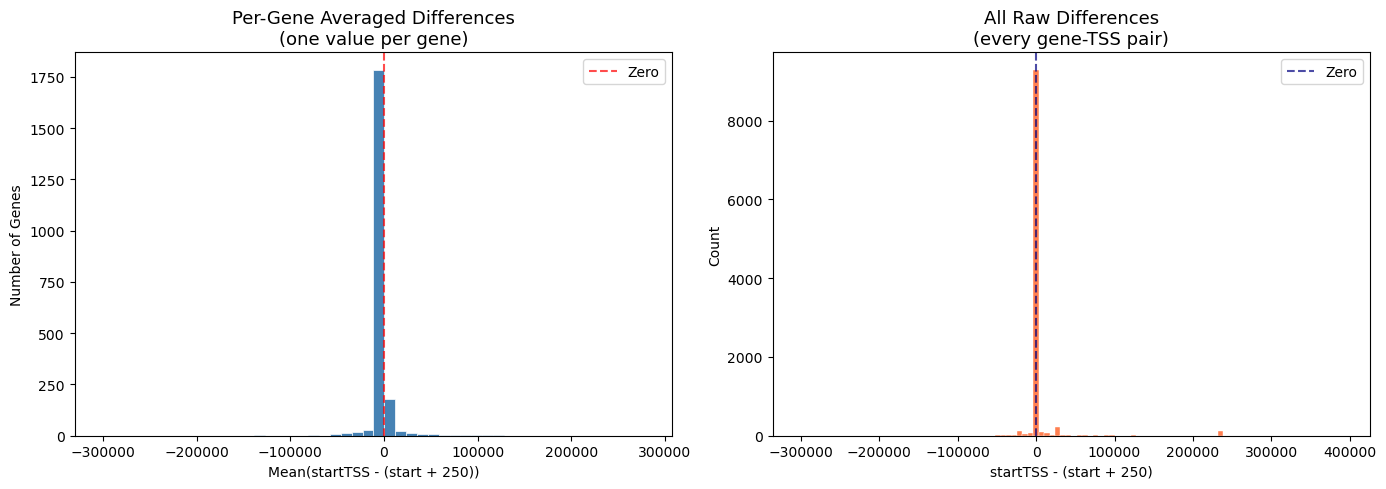

Plot saved. Genes with data: 2113 | Total pairs: 10356

=== Top 20 Largest Absolute Differences ===
  HBG2                 diff =    391,007
  C2orf88              diff =   -301,345
  HBG2                 diff =    250,823
  HBG2                 diff =    250,823
  HBG2                 diff =    250,823
  HBG2                 diff =    250,823
  HBE1                 diff =    235,509
  HBE1                 diff =    235,509
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate differences
differences = {}  # gene -> list of differences

for index, row in tss.iterrows():
    name = row['name']
    sub_gs_df = gs_df[gs_df['measuredGeneSymbol'] == name]
    
    if not sub_gs_df.empty:
        diffs = (sub_gs_df['startTSS'] - (row['start'] + 250)).tolist()
        if name not in differences:
            differences[name] = []
        differences[name].extend(diffs)

# --- Derived structures ---
# Per-gene average
gene_avg = {gene: np.mean(diffs) for gene, diffs in differences.items()}

# Flat list of all differences
all_diffs = [d for diffs in differences.values() for d in diffs]

# --- Plot 1: Per-gene averaged histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(list(gene_avg.values()), bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Per-Gene Averaged Differences\n(one value per gene)', fontsize=13)
axes[0].set_xlabel('Mean(startTSS - (start + 250))')
axes[0].set_ylabel('Number of Genes')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero')
axes[0].legend()

# --- Plot 2: All raw differences histogram ---
axes[1].hist(all_diffs, bins=100, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('All Raw Differences\n(every gene-TSS pair)', fontsize=13)
axes[1].set_xlabel('startTSS - (start + 250)')
axes[1].set_ylabel('Count')
axes[1].axvline(0, color='navy', linestyle='--', alpha=0.7, label='Zero')
axes[1].legend()

plt.tight_layout()
plt.savefig('tss_differences.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved. Genes with data: {len(gene_avg)} | Total pairs: {len(all_diffs)}")

# --- Largest differences ---
print("\n=== Top 20 Largest Absolute Differences ===")
flat_records = [
    (gene, diff) 
    for gene, diffs in differences.items() 
    for diff in diffs
]
flat_records.sort(key=lambda x: abs(x[1]), reverse=True)

for gene, diff in flat_records[:20]:
    print(f"  {gene:<20} diff = {diff:>10,.0f}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate differences
differences = {}  # gene -> list of differences
chr_mismatch_genes = []  # genes where chromosome didn't match
nan_tss_count = 0  # counter for NaN startTSS entries

for index, row in tss.iterrows():
    name = row['name']
    sub_gs_df = gs_df[gs_df['measuredGeneSymbol'] == name]
    
    if not sub_gs_df.empty:
        # Check chromosome match
        if not (sub_gs_df['chrTSS'] == row['#chr']).all():
            chr_mismatch_genes.append((name, row['#chr'], sub_gs_df['chrTSS'].unique().tolist()))
            continue

        # Check for NaN startTSS
        nan_mask = sub_gs_df['startTSS'].isna()
        nan_tss_count += nan_mask.sum()
        sub_gs_df = sub_gs_df[~nan_mask]

        if sub_gs_df.empty:
            continue

        diffs = (sub_gs_df['startTSS'] - (row['start'] + 250)).tolist()
        if name not in differences:
            differences[name] = []
        differences[name].extend(diffs)

# --- Summary ---
print(f"Genes with chromosome mismatch (skipped): {len(chr_mismatch_genes)}")
print(f"NaN startTSS entries skipped: {nan_tss_count}")
print(f"Genes with valid differences: {len(differences)}")

if chr_mismatch_genes:
    print("\nChromosome mismatches:")
    for gene, row_chr, gs_chrs in chr_mismatch_genes[:10]:
        print(f"  {gene:<20} row chr: {row_chr}  gs chrs: {gs_chrs}")
    if len(chr_mismatch_genes) > 10:
        print(f"  ... and {len(chr_mismatch_genes) - 10} more")

Genes with chromosome mismatch (skipped): 0
NaN startTSS entries skipped: 81
Genes with valid differences: 2113


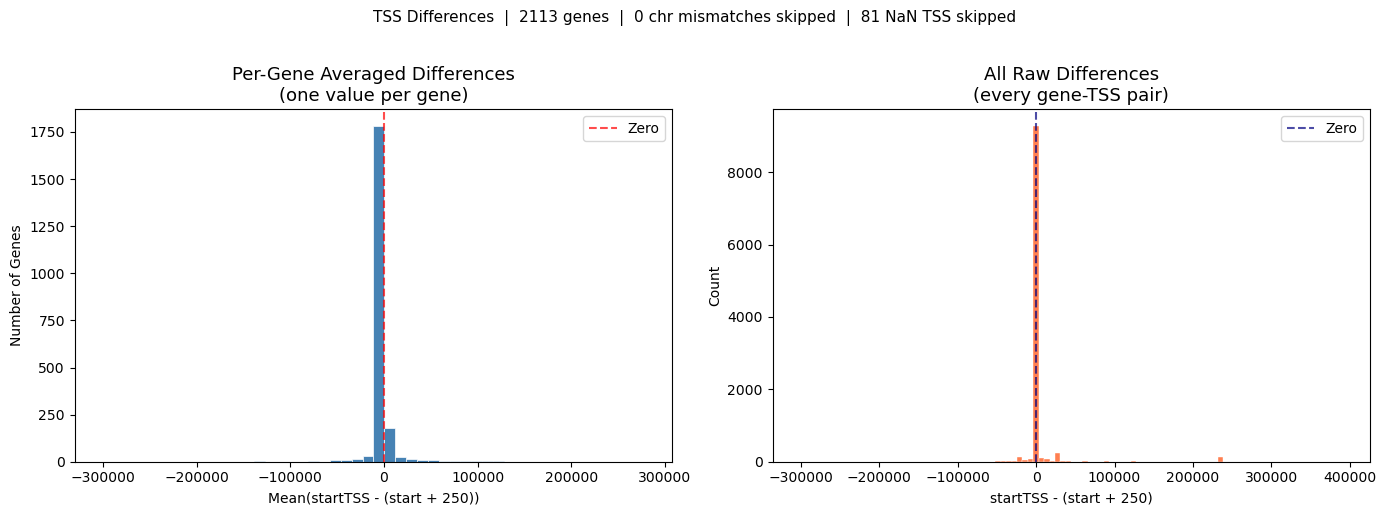


=== Top 20 Largest Absolute Differences ===
  HBG2                 diff =    391,007
  C2orf88              diff =   -301,345
  HBG2                 diff =    250,823
  HBG2                 diff =    250,823
  HBG2                 diff =    250,823
  HBG2                 diff =    250,823
  HBE1                 diff =    235,509
  HBE1                 diff =    235,509
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508
  HBE1                 diff =    235,508


In [24]:
# --- Derived structures ---
gene_avg = {gene: np.mean(diffs) for gene, diffs in differences.items()}
all_diffs = [d for diffs in differences.values() for d in diffs]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(list(gene_avg.values()), bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Per-Gene Averaged Differences\n(one value per gene)', fontsize=13)
axes[0].set_xlabel('Mean(startTSS - (start + 250))')
axes[0].set_ylabel('Number of Genes')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero')
axes[0].legend()

axes[1].hist(all_diffs, bins=100, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('All Raw Differences\n(every gene-TSS pair)', fontsize=13)
axes[1].set_xlabel('startTSS - (start + 250)')
axes[1].set_ylabel('Count')
axes[1].axvline(0, color='navy', linestyle='--', alpha=0.7, label='Zero')
axes[1].legend()

plt.suptitle(
    f'TSS Differences  |  {len(differences)} genes  |  '
    f'{len(chr_mismatch_genes)} chr mismatches skipped  |  {nan_tss_count} NaN TSS skipped',
    fontsize=11, y=1.02
)

plt.tight_layout()
plt.savefig('tss_differences.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Largest differences ---
print("\n=== Top 20 Largest Absolute Differences ===")
flat_records = [(gene, diff) for gene, diffs in differences.items() for diff in diffs]
flat_records.sort(key=lambda x: abs(x[1]), reverse=True)

for gene, diff in flat_records[:20]:
    print(f"  {gene:<20} diff = {diff:>10,.0f}")

## ok so I think the chr start and stop must be hg19?

In [29]:
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,"Gasperini et al., 2019",False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,"Gasperini et al., 2019",False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,"Gasperini et al., 2019",False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408


In [30]:
tss

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
0,chr1,35831,36331,FAM138A,0,-,ENSG00000237613,lincRNA
1,chr1,35831,36331,FAM138F,0,-,ENSG00000282591,lincRNA
2,chr1,68840,69340,OR4F5,0,+,ENSG00000186092,protein_coding
3,chr1,817120,817620,FAM87B,0,+,ENSG00000177757,lincRNA
4,chr1,827272,827772,LINC00115,0,-,ENSG00000225880,lincRNA
...,...,...,...,...,...,...,...,...
20662,chrY,21386110,21386610,PRORY,0,-,ENSG00000183146,protein_coding
20663,chrY,21594416,21594916,TTTY13,0,-,ENSG00000184991,lincRNA
20664,chrY,22298626,22299126,TTTY5,0,-,ENSG00000215560,lincRNA
20665,chrY,23198842,23199342,DAZ1,0,-,ENSG00000188120,protein_coding



Genes with midpoint->startTSS diffs:    2146
Genes with midpoint->TSS protein diffs: 2113
Chr mismatches skipped:                 0
NaN startTSS skipped:                   81


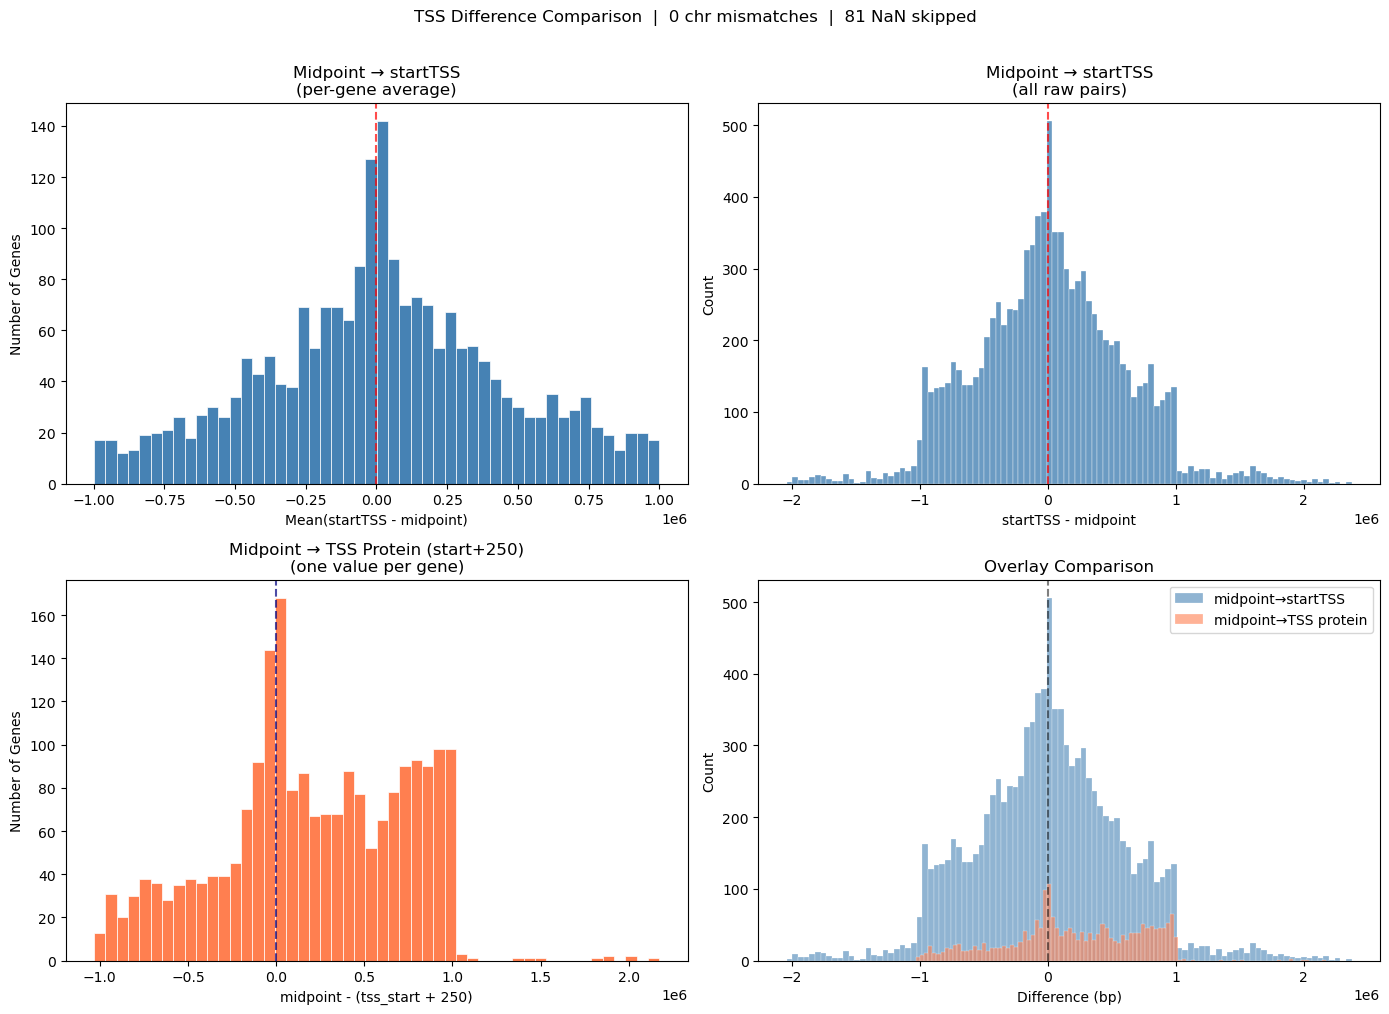


=== Top 10 Largest midpoint→startTSS differences ===
  PLP2                  2,375,166 bp
  PLP2                  2,333,586 bp
  PLP2                  2,257,896 bp
  HBE1                  2,243,606 bp
  HBE1                  2,242,886 bp
  PLP2                  2,214,453 bp
  HBE1                  2,197,786 bp
  PLP2                  2,193,122 bp
  HBE1                  2,180,846 bp
  HBE1                  2,165,466 bp

=== Top 10 Largest midpoint→TSS protein differences ===
  HBE1                  2,172,621 bp
  SEC61A1               2,041,664 bp
  MYC                   1,995,861 bp
  GATA1                 1,905,342 bp
  HDAC6                 1,889,900 bp
  PQBP1                 1,794,004 bp
  PLP2                  1,520,079 bp
  RPN1                  1,443,156 bp
  RAB7A                 1,367,897 bp
  EIF3E                 1,117,680 bp


In [36]:
#why is this nowhere, but we can verify by doing distance to the TSS maybe?

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

midpoint_diffs = {}      # gene -> list of (midpoint - startTSS)
tss_protein_diffs = {}   # gene -> (midpoint - (tss_start + 250))
chr_mismatch_genes = []
nan_tss_count = 0

for index, row in gs_df.iterrows():
    name = row['measuredGeneSymbol']
    
    # Midpoint of gs_df start/end
    midpoint = round((row['chromStart'] + row['chromEnd']) / 2)
    
    # Check for NaN startTSS
    if pd.isna(row['startTSS']):
        nan_tss_count += 1
        # continue

    # --- Diff 1: midpoint vs startTSS (within gs_df) ---
    midpoint_diffs.setdefault(name, []).append(row['startTSS'] - midpoint)

    # --- Diff 2: midpoint vs TSS protein start+250 ---
    tss_rows = tss[tss['name'] == name]
    
    if tss_rows.empty:
        continue

    # Check chromosome match
    if not (tss_rows['#chr'] == row['chrTSS']).all():
        chr_mismatch_genes.append((name, row['chrTSS'], tss_rows['#chr'].unique().tolist()))
        continue

    # Check for duplicates in tss
    if len(tss_rows) > 1:
        print(f"WARNING: {len(tss_rows)} duplicate entries in tss for gene '{name}' — using first")
    
    tss_start = tss_rows.iloc[0]['start']
    tss_protein_diffs[name] = midpoint - (tss_start + 250)

# --- Summary ---
print(f"\nGenes with midpoint->startTSS diffs:    {len(midpoint_diffs)}")
print(f"Genes with midpoint->TSS protein diffs: {len(tss_protein_diffs)}")
print(f"Chr mismatches skipped:                 {len(chr_mismatch_genes)}")
print(f"NaN startTSS skipped:                   {nan_tss_count}")

# --- Derived ---
gene_avg_midpoint  = {g: np.mean(v) for g, v in midpoint_diffs.items()}
all_midpoint_diffs = [d for v in midpoint_diffs.values() for d in v]
tss_protein_vals   = list(tss_protein_diffs.values())

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: midpoint vs startTSS
axes[0, 0].hist(list(gene_avg_midpoint.values()), bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Midpoint → startTSS\n(per-gene average)', fontsize=12)
axes[0, 0].set_xlabel('Mean(startTSS - midpoint)')
axes[0, 0].set_ylabel('Number of Genes')
axes[0, 0].axvline(0, color='red', linestyle='--', alpha=0.7)

axes[0, 1].hist(all_midpoint_diffs, bins=100, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.8)
axes[0, 1].set_title('Midpoint → startTSS\n(all raw pairs)', fontsize=12)
axes[0, 1].set_xlabel('startTSS - midpoint')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(0, color='red', linestyle='--', alpha=0.7)

# Bottom row: midpoint vs TSS protein start+250
axes[1, 0].hist(tss_protein_vals, bins=50, color='coral', edgecolor='white', linewidth=0.5)
axes[1, 0].set_title('Midpoint → TSS Protein (start+250)\n(one value per gene)', fontsize=12)
axes[1, 0].set_xlabel('midpoint - (tss_start + 250)')
axes[1, 0].set_ylabel('Number of Genes')
axes[1, 0].axvline(0, color='navy', linestyle='--', alpha=0.7)

# Overlay comparison on bottom right
axes[1, 1].hist(all_midpoint_diffs, bins=100, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.6, label='midpoint→startTSS')
axes[1, 1].hist(tss_protein_vals,   bins=100, color='coral',     edgecolor='white', linewidth=0.3, alpha=0.6, label='midpoint→TSS protein')
axes[1, 1].set_title('Overlay Comparison', fontsize=12)
axes[1, 1].set_xlabel('Difference (bp)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].legend()

plt.suptitle(
    f'TSS Difference Comparison  |  {len(chr_mismatch_genes)} chr mismatches  |  {nan_tss_count} NaN skipped',
    fontsize=12, y=1.01
)
plt.tight_layout()
# plt.savefig('tss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Largest differences ---
print("\n=== Top 10 Largest midpoint→startTSS differences ===")
flat = [(g, d) for g, v in midpoint_diffs.items() for d in v]
for gene, diff in sorted(flat, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  {gene:<20} {diff:>10,.0f} bp")

print("\n=== Top 10 Largest midpoint→TSS protein differences ===")
for gene, diff in sorted(tss_protein_diffs.items(), key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  {gene:<20} {diff:>10,.0f} bp")

In [37]:
#find the ones that are more than 1 MB
gene_list = [gene for gene, diff in tss_protein_diffs.items() if abs(diff) > 1_000_000]
# for gene, diff in sorted(tss_protein_diffs.items(), key=lambda x: abs(x[1]), reverse=True)
# gs_df[gs_df['measuredGeneSymbol'] == 'SEC61A1']
gene_list

['HBE1',
 'PSMA1',
 'HSP90AA1',
 'SEH1L',
 'EMP3',
 'PDIA6',
 'LIMK2',
 'RAB7A',
 'RPN1',
 'SEC61A1',
 'TFDP2',
 'CANX',
 'ABT1',
 'EIF3E',
 'MYC',
 'GATA1',
 'HDAC6',
 'PLP2',
 'PQBP1']

In [38]:
#now loop through gene list and see which ones
gs_df[gs_df['measuredGeneSymbol'] == 'SEC61A1']


,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
7173,FlowFISH_K562,chr3,127573842,127574362,SEC61A1|chr3:127292685-127293205:*,0.016188,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:127292685-127293205:*,7174,127573842,127574362
7174,FlowFISH_K562,chr3,127584422,127585002,SEC61A1|chr3:127303265-127303845:*,-0.000737,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:127303265-127303845:*,7175,127584422,127585002
7175,FlowFISH_K562,chr3,127595282,127595802,SEC61A1|chr3:127314125-127314645:*,-0.029855,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:127314125-127314645:*,7176,127595282,127595802
7176,FlowFISH_K562,chr3,127630062,127630562,SEC61A1|chr3:127348905-127349405:*,-0.005436,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:127348905-127349405:*,7177,127630062,127630562
7177,FlowFISH_K562,chr3,127634602,127635102,SEC61A1|chr3:127353445-127353945:*,-0.017635,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:127353445-127353945:*,7178,127634602,127635102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7301,FlowFISH_K562,chr3,129936762,129937282,SEC61A1|chr3:129655605-129656125:*,0.060648,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:129655605-129656125:*,7302,129936762,129937282
7302,FlowFISH_K562,chr3,129942102,129942642,SEC61A1|chr3:129660945-129661485:*,-0.000988,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:129660945-129661485:*,7303,129942102,129942642
7303,FlowFISH_K562,chr3,130048702,130049202,SEC61A1|chr3:129767545-129768045:*,0.017677,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:129767545-129768045:*,7304,130048702,130049202
7304,FlowFISH_K562,chr3,130084522,130085062,SEC61A1|chr3:129803365-129803905:*,-0.054491,chr3,128051641.0,128051642.0,SEC61A1,...,Fulco2019,False,NaN,NaN,NaN,NaN,FlowFISH_K562|SEC61A1|chr3:129803365-129803905:*,7305,130084522,130085062



Genes with midpoint->startTSS diffs:    2146
Genes with midpoint->TSS protein diffs: 2113
Chr mismatches skipped:                 0
NaN startTSS skipped:                   81


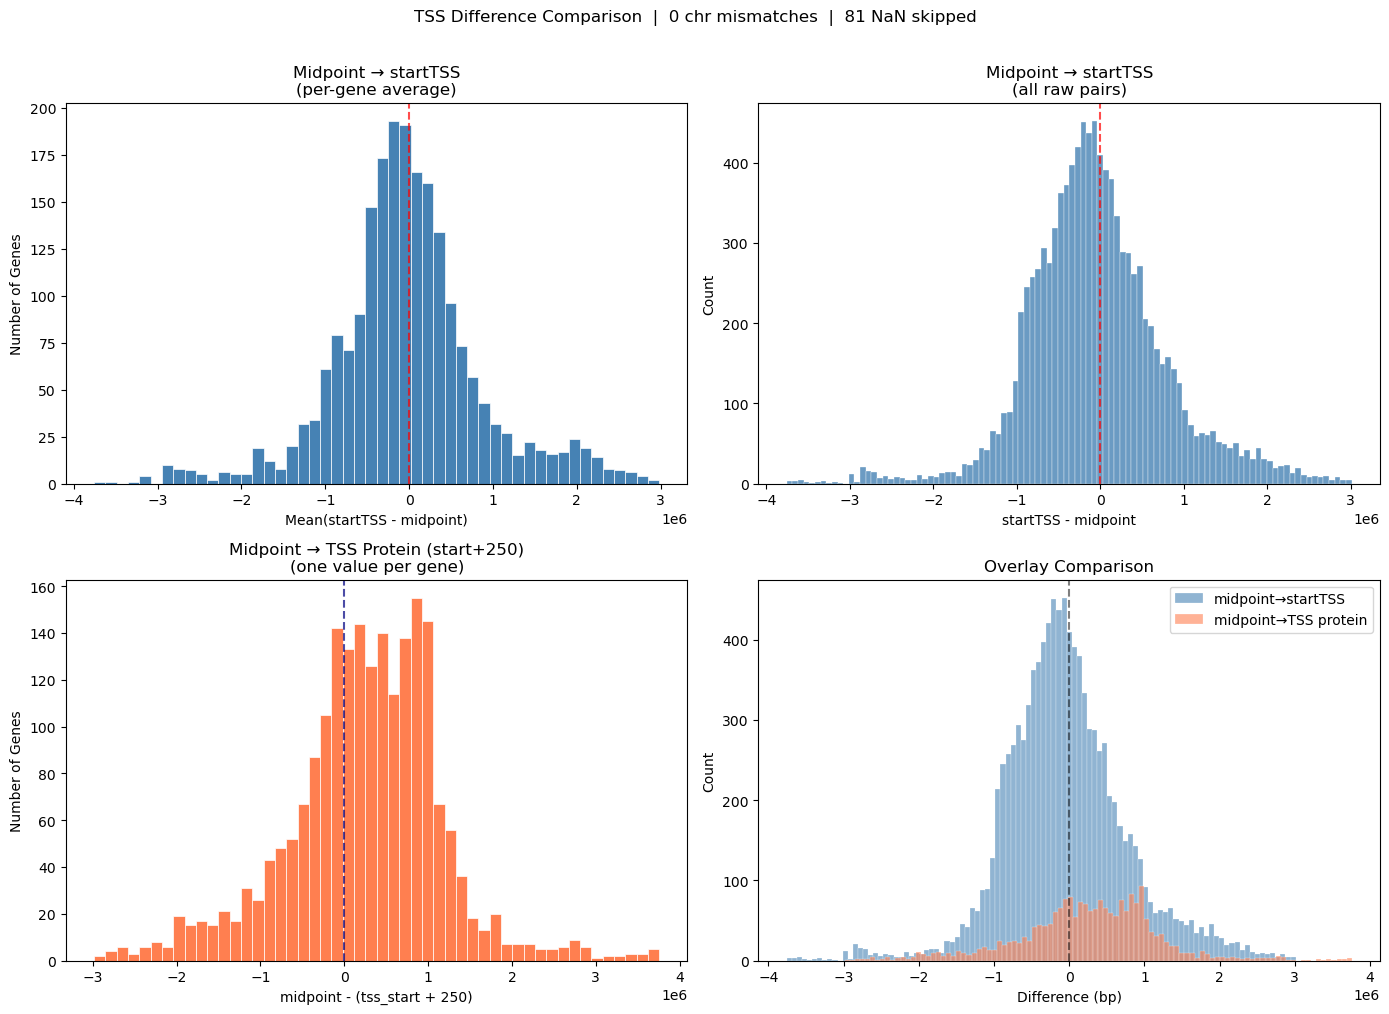


=== Top 10 Largest midpoint→startTSS differences ===
  PSMB7                -3,756,511 bp
  HEMGN                -3,749,409 bp
  ANP32B               -3,710,903 bp
  ANP32B               -3,665,912 bp
  NANS                 -3,637,525 bp
  C9orf16              -3,635,465 bp
  C9orf78              -3,615,904 bp
  RPL12                -3,607,622 bp
  C9orf78              -3,588,798 bp
  C9orf78              -3,576,274 bp

=== Top 10 Largest midpoint→TSS protein differences ===
  PSMB7                 3,756,481 bp
  HEMGN                 3,749,349 bp
  ANP32B                3,711,058 bp
  NANS                  3,637,588 bp
  C9orf16               3,635,466 bp
  C9orf78               3,616,473 bp
  RPL12                 3,607,594 bp
  RAD23B                3,494,815 bp
  SET                   3,485,341 bp
  COQ4                  3,473,218 bp


In [28]:
#now instead of using the start and stop columns, use this name column

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

midpoint_diffs = {}      # gene -> list of (midpoint - startTSS)
tss_protein_diffs = {}   # gene -> (midpoint - (tss_start + 250))
chr_mismatch_genes = []
nan_tss_count = 0

for index, row in gs_df.iterrows():
    name = row['measuredGeneSymbol']
    
    # Midpoint of gs_df start/end
    # midpoint = round((row['chromStart'] + row['chromEnd']) / 2)
    #example of name column: C19orf43|chr19:12313025-12313565:*	
    tempname = row['name']
    temppos = tempname.split('|')[1] #chr19:12313025-12313565:*
    temppos = temppos.split(':')[1] #12313025-12313565
    start, end = temppos.split('-')
    start = int(start)
    end = int(end)
    midpoint = round((start + end) / 2)
    
    # Check for NaN startTSS
    if pd.isna(row['startTSS']):
        nan_tss_count += 1
        # continue

    # --- Diff 1: midpoint vs startTSS (within gs_df) ---
    midpoint_diffs.setdefault(name, []).append(row['startTSS'] - midpoint)

    # --- Diff 2: midpoint vs TSS protein start+250 ---
    tss_rows = tss[tss['name'] == name]
    
    if tss_rows.empty:
        continue

    # Check chromosome match
    if not (tss_rows['#chr'] == row['chrTSS']).all():
        chr_mismatch_genes.append((name, row['chrTSS'], tss_rows['#chr'].unique().tolist()))
        continue

    # Check for duplicates in tss
    if len(tss_rows) > 1:
        print(f"WARNING: {len(tss_rows)} duplicate entries in tss for gene '{name}' — using first")
    
    tss_start = tss_rows.iloc[0]['start']
    tss_protein_diffs[name] = midpoint - (tss_start + 250)

# --- Summary ---
print(f"\nGenes with midpoint->startTSS diffs:    {len(midpoint_diffs)}")
print(f"Genes with midpoint->TSS protein diffs: {len(tss_protein_diffs)}")
print(f"Chr mismatches skipped:                 {len(chr_mismatch_genes)}")
print(f"NaN startTSS skipped:                   {nan_tss_count}")

# --- Derived ---
gene_avg_midpoint  = {g: np.mean(v) for g, v in midpoint_diffs.items()}
all_midpoint_diffs = [d for v in midpoint_diffs.values() for d in v]
tss_protein_vals   = list(tss_protein_diffs.values())

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: midpoint vs startTSS
axes[0, 0].hist(list(gene_avg_midpoint.values()), bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Midpoint → startTSS\n(per-gene average)', fontsize=12)
axes[0, 0].set_xlabel('Mean(startTSS - midpoint)')
axes[0, 0].set_ylabel('Number of Genes')
axes[0, 0].axvline(0, color='red', linestyle='--', alpha=0.7)

axes[0, 1].hist(all_midpoint_diffs, bins=100, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.8)
axes[0, 1].set_title('Midpoint → startTSS\n(all raw pairs)', fontsize=12)
axes[0, 1].set_xlabel('startTSS - midpoint')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(0, color='red', linestyle='--', alpha=0.7)

# Bottom row: midpoint vs TSS protein start+250
axes[1, 0].hist(tss_protein_vals, bins=50, color='coral', edgecolor='white', linewidth=0.5)
axes[1, 0].set_title('Midpoint → TSS Protein (start+250)\n(one value per gene)', fontsize=12)
axes[1, 0].set_xlabel('midpoint - (tss_start + 250)')
axes[1, 0].set_ylabel('Number of Genes')
axes[1, 0].axvline(0, color='navy', linestyle='--', alpha=0.7)

# Overlay comparison on bottom right
axes[1, 1].hist(all_midpoint_diffs, bins=100, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.6, label='midpoint→startTSS')
axes[1, 1].hist(tss_protein_vals,   bins=100, color='coral',     edgecolor='white', linewidth=0.3, alpha=0.6, label='midpoint→TSS protein')
axes[1, 1].set_title('Overlay Comparison', fontsize=12)
axes[1, 1].set_xlabel('Difference (bp)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].legend()

plt.suptitle(
    f'TSS Difference Comparison  |  {len(chr_mismatch_genes)} chr mismatches  |  {nan_tss_count} NaN skipped',
    fontsize=12, y=1.01
)
plt.tight_layout()
# plt.savefig('tss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Largest differences ---
print("\n=== Top 10 Largest midpoint→startTSS differences ===")
flat = [(g, d) for g, v in midpoint_diffs.items() for d in v]
for gene, diff in sorted(flat, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  {gene:<20} {diff:>10,.0f} bp")

print("\n=== Top 10 Largest midpoint→TSS protein differences ===")
for gene, diff in sorted(tss_protein_diffs.items(), key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  {gene:<20} {diff:>10,.0f} bp")

In [ ]:
#just assume start and stop are hg38, seems to line up with the thing. Can rescore an existing method to validate it
#center at my TSS and validate it like that?

#can ask alireza too maybe? look at their code for how they calculate it
#but use my gh38 files for tss and then use the start and end for 

#but its' so strange. Using midpoint from hg19 name is definitely hg19 but it's off for both the TSS and the tss in the gs df
#so then wtf is going on?? We have to look more into it I guess?
#figure out where this came from and if this table uses hg38 or not!

In [39]:
tss

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
0,chr1,35831,36331,FAM138A,0,-,ENSG00000237613,lincRNA
1,chr1,35831,36331,FAM138F,0,-,ENSG00000282591,lincRNA
2,chr1,68840,69340,OR4F5,0,+,ENSG00000186092,protein_coding
3,chr1,817120,817620,FAM87B,0,+,ENSG00000177757,lincRNA
4,chr1,827272,827772,LINC00115,0,-,ENSG00000225880,lincRNA
...,...,...,...,...,...,...,...,...
20662,chrY,21386110,21386610,PRORY,0,-,ENSG00000183146,protein_coding
20663,chrY,21594416,21594916,TTTY13,0,-,ENSG00000184991,lincRNA
20664,chrY,22298626,22299126,TTTY5,0,-,ENSG00000215560,lincRNA
20665,chrY,23198842,23199342,DAZ1,0,-,ENSG00000188120,protein_coding


# another approach is to look at TSS sites for well known locus

In [54]:
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,"Gasperini et al., 2019",False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,"Gasperini et al., 2019",False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,"Gasperini et al., 2019",False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408


In [53]:
tss

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
0,chr1,35831,36331,FAM138A,0,-,ENSG00000237613,lincRNA
1,chr1,35831,36331,FAM138F,0,-,ENSG00000282591,lincRNA
2,chr1,68840,69340,OR4F5,0,+,ENSG00000186092,protein_coding
3,chr1,817120,817620,FAM87B,0,+,ENSG00000177757,lincRNA
4,chr1,827272,827772,LINC00115,0,-,ENSG00000225880,lincRNA
...,...,...,...,...,...,...,...,...
20662,chrY,21386110,21386610,PRORY,0,-,ENSG00000183146,protein_coding
20663,chrY,21594416,21594916,TTTY13,0,-,ENSG00000184991,lincRNA
20664,chrY,22298626,22299126,TTTY5,0,-,ENSG00000215560,lincRNA
20665,chrY,23198842,23199342,DAZ1,0,-,ENSG00000188120,protein_coding


In [ ]:
#let's look at GATA1
#gemini claims hg19: ~48,644,962 (chrX), hg38: ~48,786,554 (chrX)
temp = tss[tss['name'] == 'GATA1']
print(temp['#chr'].values, temp['start'].values+250)
48786573-48786554 #19 off is pretty close!

['chrX'] [48786573]


19

In [48]:
#now look at gsdf
gs_df[gs_df['measuredGeneSymbol'] == 'GATA1']['startTSS'].values

array([48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 48786554., 48786554.,
       48786554., 48786554., 48786554., 48786554., 

In [ ]:
#wtf is this?????? It's algo hg38 bro wtf


In [ ]:
#ok let's now look at MYC
temp = tss[tss['name'] == 'MYC']
print(temp['#chr'].values, temp['start'].values+250)
127735434-127736068 #several hundred off???

['chr8'] [127736068]


-634

In [ ]:
#let's check the gs df
gs_df[gs_df['measuredGeneSymbol'] == 'MYC']['startTSS'].values

#literally hg38 bro what is this

array([1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
       1.27735434e+08, 1.27735434e+08, 1.27735434e+08, 1.27735434e+08,
      

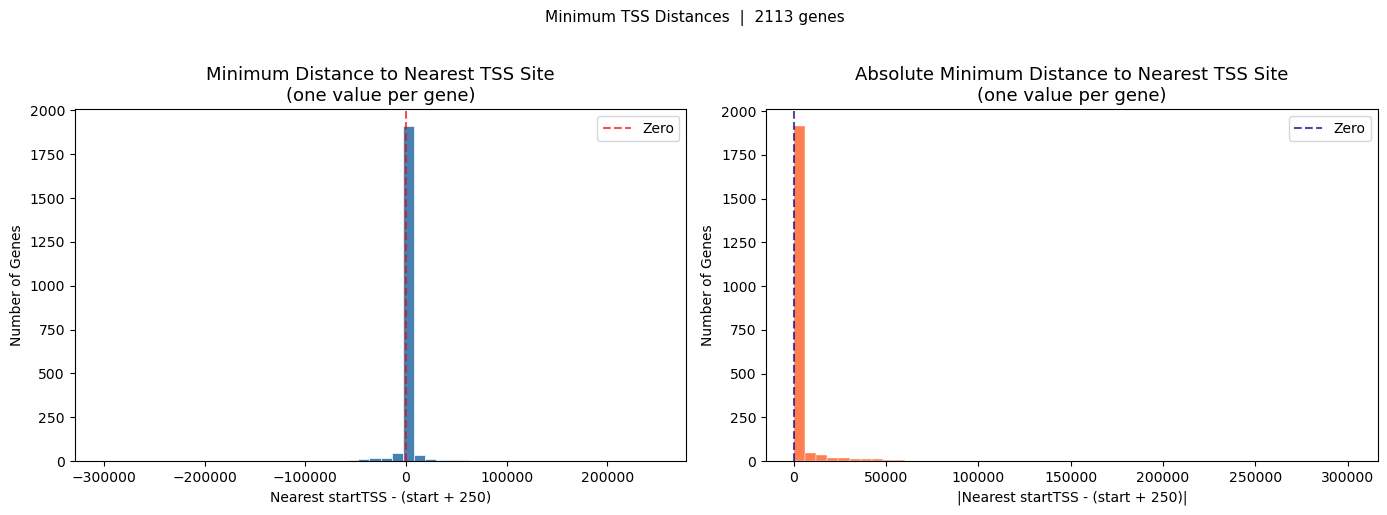

Plot saved. Genes with data: 2113

=== Top 20 Largest Minimum Absolute Differences ===
  C2orf88              diff =   -301,345
  HBG2                 diff =    250,823
  HBE1                 diff =    235,508
  MITF                 diff =   -197,164
  EIF3E                diff =    186,602
  ZNF280D              diff =    184,484
  TNRC6B               diff =   -133,107
  STEAP1B              diff =    132,642
  NDUFAF6              diff =   -129,218
  PSMA1                diff =    123,190
  SNX9                 diff =   -122,783
  TFDP2                diff =    120,878
  CCND3                diff =    108,508
  CCDC26               diff =    105,220
  ANK1                 diff =     99,139
  EBNA1BP2             diff =     98,620
  RMI2                 diff =    -95,818
  TBCA                 diff =     92,418
  CGGBP1               diff =     90,888
  SMYD3                diff =     89,899


In [52]:
#ok so the reason we may be getting 300kb is because the it uses alternative TSS?
#Let's check and see if there's any TSS and use the minimum distance. REf seq uses just one

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate differences - minimum absolute distance per tss row
differences = {}  # gene -> minimum absolute difference

for index, row in tss.iterrows():
    name = row['name']
    sub_gs_df = gs_df[gs_df['measuredGeneSymbol'] == name]
    
    if not sub_gs_df.empty:
        tss_point = row['start'] + 250
        diffs = sub_gs_df['startTSS'] - tss_point
        # Take the value with minimum absolute distance
        min_idx = diffs.abs().idxmin()
        min_diff = diffs[min_idx]
        differences[name] = min_diff

# --- Derived structures ---
all_diffs = list(differences.values())

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: histogram of min differences
axes[0].hist(all_diffs, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Minimum Distance to Nearest TSS Site\n(one value per gene)', fontsize=13)
axes[0].set_xlabel('Nearest startTSS - (start + 250)')
axes[0].set_ylabel('Number of Genes')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero')
axes[0].legend()

# Plot 2: absolute minimum distances
axes[1].hist([abs(d) for d in all_diffs], bins=50, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('Absolute Minimum Distance to Nearest TSS Site\n(one value per gene)', fontsize=13)
axes[1].set_xlabel('|Nearest startTSS - (start + 250)|')
axes[1].set_ylabel('Number of Genes')
axes[1].axvline(0, color='navy', linestyle='--', alpha=0.7, label='Zero')
axes[1].legend()

plt.suptitle(f'Minimum TSS Distances  |  {len(differences)} genes', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('tss_min_differences.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved. Genes with data: {len(differences)}")

# --- Largest differences ---
print("\n=== Top 20 Largest Minimum Absolute Differences ===")
sorted_diffs = sorted(differences.items(), key=lambda x: abs(x[1]), reverse=True)
for gene, diff in sorted_diffs[:20]:
    print(f"  {gene:<20} diff = {diff:>10,.0f}")

In [ ]:
#look at hbe1
temp = tss[tss['name'] == 'HBE1']
temp['#chr'].values, temp['start'].values+250


(array(['chr11'], dtype=object), array([5270143]))

In [58]:
temp

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
10762,chr11,5269893,5270393,HBE1,0,-,ENSG00000213931,protein_coding


In [57]:
gs_df[gs_df['measuredGeneSymbol'] == 'HBE1']['startTSS'].values

array([5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505652., 5505651., 5505652.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 5505651.,
       5505651., 5505651., 5505651., 5505651., 5505651., 55056

In [ ]:
#this transcript is a kilobase, but for some reason they are using the 

In [60]:
gs_df[gs_df['measuredGeneSymbol'] == 'HBE1'].columns

Index(['dataset', 'chrom', 'chromStart', 'chromEnd', 'name', 'EffectSize',
       'chrTSS', 'startTSS', 'endTSS', 'measuredGeneSymbol', 'Significant',
       'pValueAdjusted', 'PowerAtEffectSize25', 'ValidConnection', 'CellType',
       'Reference', 'Regulated', 'PowerAtEffectSize10', 'PowerAtEffectSize15',
       'PowerAtEffectSize20', 'PowerAtEffectSize50', 'pair_uid', 'merged_uid',
       'merged_start', 'merged_end'],
      dtype='object')

In [63]:
for gene, diff in sorted_diffs:
    if abs(diff) < 1000:
        break
    print(f"  {gene:<20} diff = {diff:>10,.0f}")

  C2orf88              diff =   -301,345
  HBG2                 diff =    250,823
  HBE1                 diff =    235,508
  MITF                 diff =   -197,164
  EIF3E                diff =    186,602
  ZNF280D              diff =    184,484
  TNRC6B               diff =   -133,107
  STEAP1B              diff =    132,642
  NDUFAF6              diff =   -129,218
  PSMA1                diff =    123,190
  SNX9                 diff =   -122,783
  TFDP2                diff =    120,878
  CCND3                diff =    108,508
  CCDC26               diff =    105,220
  ANK1                 diff =     99,139
  EBNA1BP2             diff =     98,620
  RMI2                 diff =    -95,818
  TBCA                 diff =     92,418
  CGGBP1               diff =     90,888
  SMYD3                diff =     89,899
  SLC39A8              diff =     86,066
  MSN                  diff =    -79,266
  RAP1A                diff =    -77,564
  FAM49B               diff =     77,256
  CELF1         

In [62]:
sorted_diffs

[('C2orf88', -301345.0),
 ('HBG2', 250823.0),
 ('HBE1', 235508.0),
 ('MITF', -197164.0),
 ('EIF3E', 186602.0),
 ('ZNF280D', 184484.0),
 ('TNRC6B', -133107.0),
 ('STEAP1B', 132642.0),
 ('NDUFAF6', -129218.0),
 ('PSMA1', 123190.0),
 ('SNX9', -122783.0),
 ('TFDP2', 120878.0),
 ('CCND3', 108508.0),
 ('CCDC26', 105220.0),
 ('ANK1', 99139.0),
 ('EBNA1BP2', 98620.0),
 ('RMI2', -95818.0),
 ('TBCA', 92418.0),
 ('CGGBP1', 90888.0),
 ('SMYD3', 89899.0),
 ('SLC39A8', 86066.0),
 ('MSN', -79266.0),
 ('RAP1A', -77564.0),
 ('FAM49B', 77256.0),
 ('CELF1', 76544.0),
 ('MAGEA6', 70993.0),
 ('CDC42EP3', 66268.0),
 ('COX7A2L', 63844.0),
 ('RTN4', 62022.0),
 ('TMCO1', 58832.0),
 ('PCGF5', -57589.0),
 ('PLAGL1', 56182.0),
 ('ZNF131', -55666.0),
 ('ERCC1', 54908.0),
 ('SEC14L1', -54206.0),
 ('SUB1', -53865.0),
 ('HSP90AA1', 52523.0),
 ('ANTXR2', 52130.0),
 ('BRD4', 52093.0),
 ('CAPZA2', -51438.0),
 ('COL18A1', -50372.0),
 ('CMIP', -50178.0),
 ('C1D', 47920.0),
 ('ANAPC5', 47433.0),
 ('MEG3', -46697.0),
 ('PPI

In [ ]:
#ok so HBE1 is actually super short, but genecards and gencode and thus the chrstart is based on a lot of bakwas
#so it's best to just use the refseq one
#that's what is used for training actually

In [ ]:
#so let's ask andreas a few things

#first if chrstart and chrend are hg38

#then what's up with the tss being so off from this refseq file.

#why such a discrepancy in the TSS column? Looked at this HBE1 gene and it is like a 1kb transcript form refseq

#I think refseq is just better, we did it right in the first place lol! And I think the chrstrat and chrend are hg38?

#And I think the chr start and end are roughly right as well lol! probably hg38. But at this point let's ask Andreas
#I cannot find it anywhere.

#logically it has to be hg38, wouldn't make sense otherwise. So we'll just assume that and do it!

#we can use DNase for K562 to verify as well!

# verifying with k562 DNase

In [2]:
#let's load it in from the zarr array to get an idea of the peaks and if they overlap start and stop
#then we can use the refseq lifted over coordinates and it should be fine?

#load the tss file again
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t", header=None)

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
df = pd.read_csv(path, sep="\t")

k562_file = '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/K562_DNase.npz'
with np.load(k562_file) as k562_file:
    k562 = {key: np.array(k562_file[key]) for key in k562_file}

In [3]:
df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,"Gasperini et al., 2019",False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,"Gasperini et al., 2019",False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,"Gasperini et al., 2019",False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408


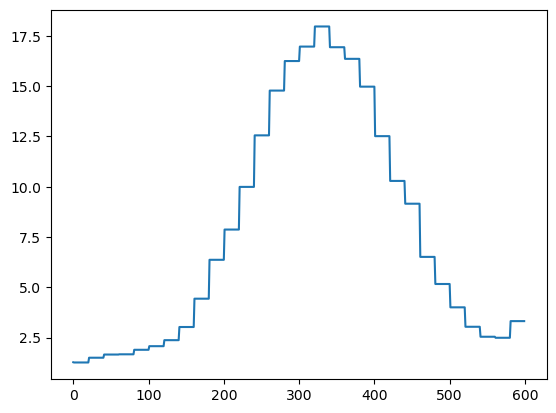

In [5]:
temp = df.iloc[0]
chrom = temp['chrom']
start = temp['chromStart']
end = temp['chromEnd']
track = k562[chrom][0,start-50:end+50]

plt.plot(track) #is

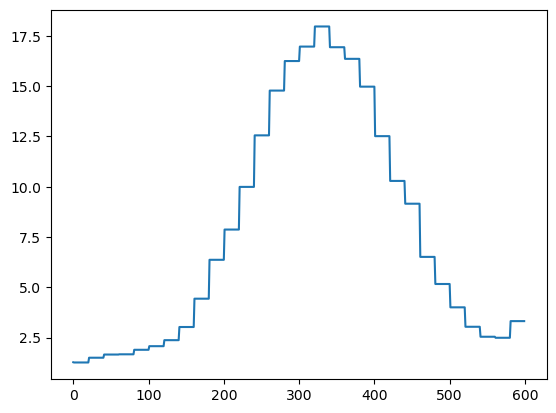

In [6]:
#let's look at the next
temp = df.iloc[1]
plt.plot(k562[temp['chrom']][0,temp['chromStart']-50:temp['chromEnd']+50])

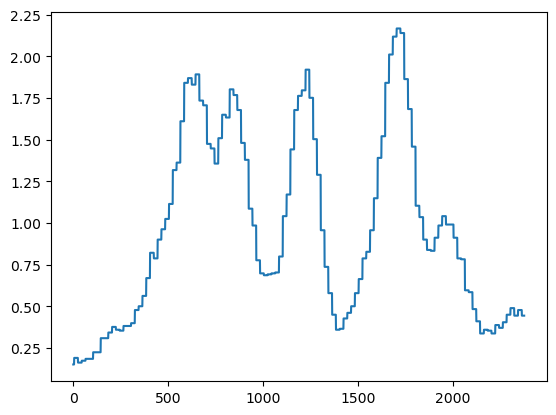

In [8]:
#and the next one
temp = df.iloc[2]
plt.plot(k562[temp['chrom']][0,temp['chromStart']-50:temp['chromEnd']+50])

In [10]:
df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,"Gasperini et al., 2019",False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,"Gasperini et al., 2019",False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,"Gasperini et al., 2019",False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408


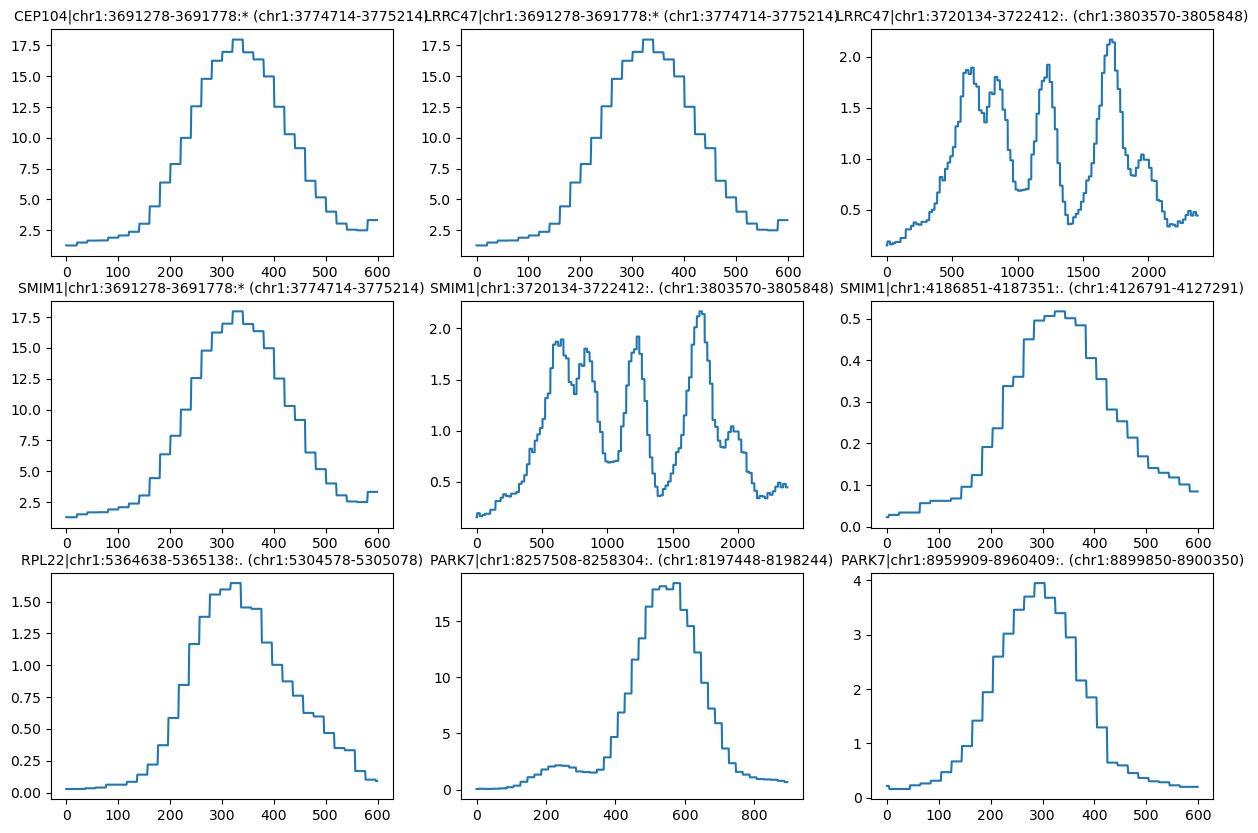

In [9]:
#let's do multiple subplots with 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i in range(9):
    temp = df.iloc[i]
    track = k562[temp['chrom']][0,temp['chromStart']-50:temp['chromEnd']+50]
    axes[i//3, i%3].plot(track)
    axes[i//3, i%3].set_title(f"{temp['name']} ({temp['chrom']}:{temp['chromStart']}-{temp['chromEnd']})", fontsize=10)

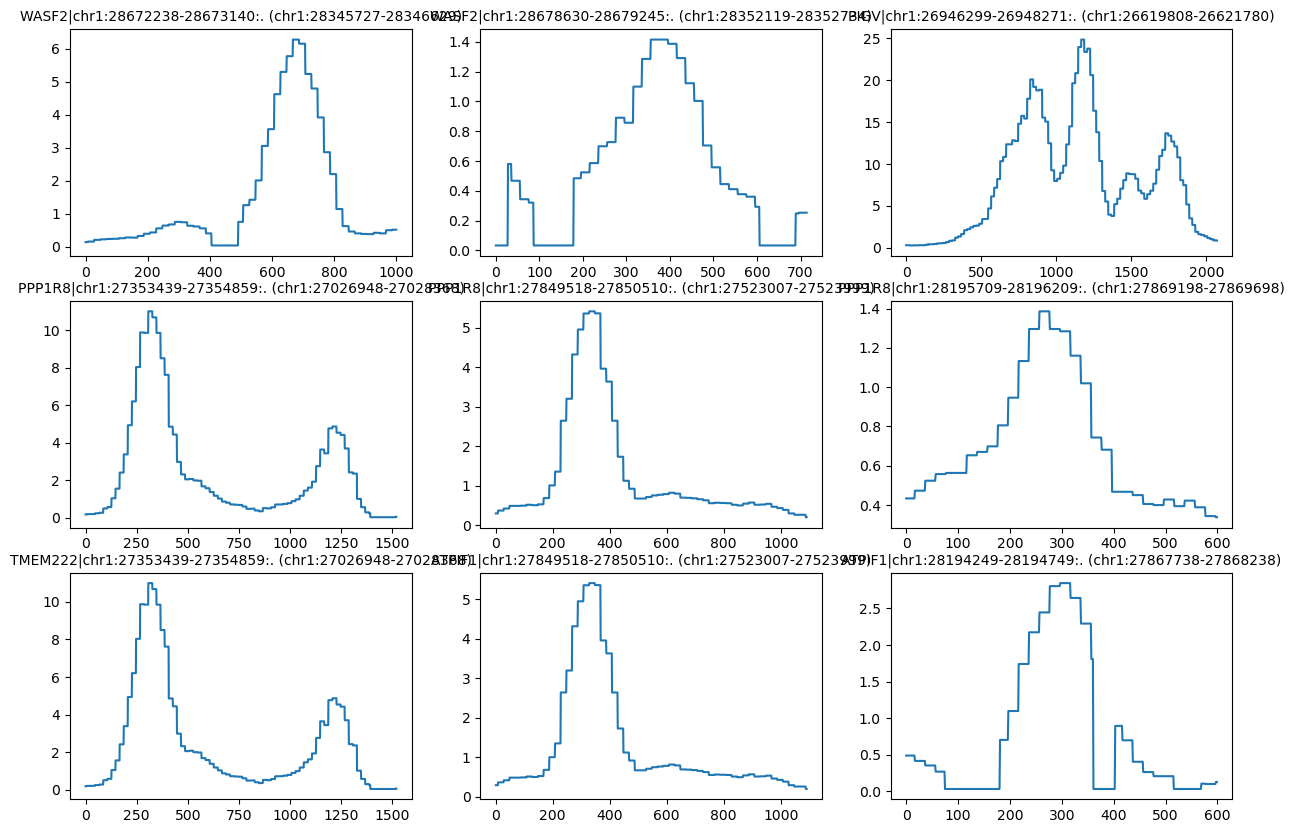

In [13]:
#let's do multiple subplots with 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
start = 99
for i in range(start, start+9):
    temp = df.iloc[i]
    i = i-start
    track = k562[temp['chrom']][0,temp['chromStart']-50:temp['chromEnd']+50]
    axes[i//3, i%3].plot(track)
    axes[i//3, i%3].set_title(f"{temp['name']} ({temp['chrom']}:{temp['chromStart']}-{temp['chromEnd']})", fontsize=10)

In [ ]:
#I can definitely verify that it IS hg38!!
#we solved our problems finally, so we can use these chrstart and stop!


# next steps

look at cage trained model, see how values change visually by muting the peak

Figure out how to mute the peak and if it affects all TSS, not jus tthe 1

Can score canonical and all TSS using the alternate TSS scores. We can use that same mask from the dataset for it!